# 08 - Descriptive Analysis

Exploration of:
- lateness/OTP distribution
- ridership
- sports/peak overlap
- weather
- line-year/day/month trends
- missingness 
- schedule structure 
- lag features

## Setup

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

BASEPATH = "../data"

df = pd.read_parquet(f"{BASEPATH}/7_df_departure_ready.parquet")

# 6-minute OTP threshold, used throughout this project's 09+ notebooks
df["on_time"] = df["lateness"] < 6

df.shape

## Descriptives on final reduced df

- Target distribution (`lateness`, and binary on_time - target var)
- Row counts by year/line, missingness overview

In [2]:
# Target variable = terminal lateness
print(df["lateness"].describe())
print(f"\nOverall OTP: {df['on_time'].mean():.4%}")

count    1.551754e+06
mean     3.418282e+00
std      8.152469e+00
min      0.000000e+00
25%      0.000000e+00
50%      1.000000e+00
75%      4.000000e+00
max      1.430000e+03
Name: lateness, dtype: float64

Overall OTP: 82.5099%


In [3]:
# by year
otp_by_year = df.groupby("year")["on_time"].agg(["mean", "count"])
otp_by_year.columns = ["otp", "n_runs"]
otp_by_year.to_parquet(f"{BASEPATH}/8_otp_by_year.parquet")
otp_by_year

,otp,n_runs
year,,
2017,0.799850,238296
2018,0.806960,138298
2019,0.843067,190170
2020,0.871887,111370
2021,0.853797,142884
2022,0.857669,174031
2023,0.856571,175481
2024,0.807986,187033
2025,0.762311,194191


Overall OTP = 82.51%, with a peak around middle of dataset in 2020 (with smallest n) and lower values in edge years. 2025 is the low point by a wide margin, which will make for a difficult test set

In [4]:
# Table A.1 formatting -- systemwide OTP by year, matches report Appendix A.6/A.1
otp_by_year_display = otp_by_year.copy()
otp_by_year_display["otp"] = (otp_by_year_display["otp"] * 100).round(2).astype(str) + "%"
otp_by_year_display

,otp,n_runs
year,,
2017,79.98%,238296
2018,80.7%,138298
2019,84.31%,190170
2020,87.19%,111370
2021,85.38%,142884
2022,85.77%,174031
2023,85.66%,175481
2024,80.8%,187033
2025,76.23%,194191


### OTP threshold sensitivity (quick check, not exhaustive)

How much does systemwide OTP move if the lateness cutoff shifts off the current 6-minute standard?
Backs Section 5.2's "3 to 4% of all runs finish just past the OTP threshold, between 6 and 7 minutes
late" claim -- not a full severity/tail or line-ranking breakdown, just the headline sensitivity.

In [5]:
threshold_rows = []
for thresh in [5, 6, 7, 10]:
    late_mask = df["lateness"] >= thresh
    n_late = int(late_mask.sum())
    print(f"<{thresh} min: OTP={1 - late_mask.mean():.4%}, late={n_late:,} ({late_mask.mean():.2%})")
    threshold_rows.append({"threshold_min": thresh, "otp": 1 - late_mask.mean(), "n_late": n_late})

n_late_6 = int((df["lateness"] >= 6).sum())
n_late_7 = int((df["lateness"] >= 7).sum())
reclassified = n_late_6 - n_late_7
print(f"\nRuns reclassified late-under-6min but not late-under-7min: {reclassified:,} "
      f"({reclassified / len(df):.2%} of all {len(df):,} runs)")

threshold_sensitivity = pd.DataFrame(threshold_rows)
threshold_sensitivity["n_total"] = len(df)
threshold_sensitivity["reclassified_6to7"] = reclassified
threshold_sensitivity.to_parquet(f"{BASEPATH}/8_threshold_sensitivity.parquet")

<5 min: OTP=78.0932%, late=339,940 (21.91%)
<6 min: OTP=82.5099%, late=271,403 (17.49%)
<7 min: OTP=85.7847%, late=220,587 (14.22%)
<10 min: OTP=91.7616%, late=127,839 (8.24%)

Runs reclassified late-under-6min but not late-under-7min: 50,816 (3.27% of all 1,551,754 runs)


## Schedule structure

- `sched_headway_prior_min`/`sched_headway_next_min`, `n_scheduled_stops_pctile_route`, `is_inbound`
- Lateness vs. schedule-structure features

In [6]:
# scheduled headway to the previous/next trip, same line+direction+day
print(df[["sched_headway_prior_min", "sched_headway_next_min"]].describe())
print("\ncorr with lateness:")
print(df[["lateness", "sched_headway_prior_min", "sched_headway_next_min"]].corr()["lateness"])

       sched_headway_prior_min  sched_headway_next_min
count             1.476539e+06            1.476539e+06
mean              5.095026e+01            5.095026e+01
std               3.186911e+01            3.186911e+01
min               0.000000e+00           -0.000000e+00
25%               3.000000e+01            3.000000e+01
50%               5.300000e+01            5.300000e+01
75%               6.000000e+01            6.000000e+01
max               1.180000e+03            1.180000e+03

corr with lateness:
lateness                   1.000000
sched_headway_prior_min   -0.020574
sched_headway_next_min    -0.009305
Name: lateness, dtype: float64


In [7]:
# headway in coarse bins -- easier to read the shape of the relationship than a raw correlation
headway_bins = [-1, 15, 30, 45, 60, 90, np.inf]
headway_labels = ["0-15min", "15-30min", "30-45min", "45-60min", "60-90min", "90min+"]

df["sched_headway_prior_bin"] = pd.cut(df["sched_headway_prior_min"], bins = headway_bins, labels = headway_labels)
df.groupby("sched_headway_prior_bin", observed = True)["lateness"].agg(["mean", "median", "count"])

,mean,median,count
sched_headway_prior_bin,,,
0-15min,4.876946,2.0,112406
15-30min,3.331662,1.0,362333
30-45min,3.726785,1.0,190861
45-60min,3.161590,1.0,542863
60-90min,3.186146,1.0,147282
90min+,3.818153,1.0,120794


In [8]:
# express/local proxy: this trip's stop-count percentile within its exact scheduled route
print(df["n_scheduled_stops_pctile_route"].describe())

pctile_bins = [-0.01, 0.25, 0.5, 0.75, 1.01]
pctile_labels = ["0-25pct", "25-50pct", "50-75pct", "75-100pct"]
df["n_scheduled_stops_pctile_bin"] = pd.cut(df["n_scheduled_stops_pctile_route"], bins = pctile_bins, labels = pctile_labels)
df.groupby("n_scheduled_stops_pctile_bin", observed = True)["lateness"].agg(["mean", "median", "count"])

count    1.550273e+06
mean     5.000974e-01
std      1.748055e-01
min      7.653061e-05
25%      4.998446e-01
50%      5.105502e-01
75%      5.661765e-01
max      1.000000e+00
Name: n_scheduled_stops_pctile_route, dtype: float64


,mean,median,count
n_scheduled_stops_pctile_bin,,,
0-25pct,3.673315,1.0,187257
25-50pct,3.537044,1.0,249687
50-75pct,3.305508,1.0,1052780
75-100pct,4.112240,2.0,60549


In [9]:
# inbound (toward Center City) vs outbound
df.groupby("is_inbound", observed = True)["lateness"].agg(["mean", "median", "count"])

,mean,median,count
is_inbound,,,
False,3.961827,1.0,751412
True,2.907967,1.0,800342


Headway barely correlates with lateness in raw form (-0.02) but the binned view shows the tightest headway bucket (0-15min) is worst by far (4.88 mean vs ~3.2-3.8 elsewhere). This could be trains inheriting congestion delay from whatever just preceded them.

`n_scheduled_stops_pctile_route` shows the top quartile (relatively more stops than other trips on the same exact route) running about 0.8min later on average than the rest which makes sense. More scheduled stops provide more opportunity to pick up delays.

`is_inbound` shows a really large mean difference for a single binary feature: outbound runs (away from Center City) are on average almost a minute later than inbound runs.

## Ridership

- `avg_daily_boards_monthly` vs. lateness

In [10]:
# Ridership (line level)
line_level_ridership = df.groupby("line", observed = True).agg(
    otp = ("on_time", "mean"),
    n_runs = ("lateness", "size"),
    avg_daily_boards_monthly = ("avg_daily_boards_monthly", "mean"),
    total_additions = ("service_additions", "sum"),
    total_removals = ("service_removals", "sum"),
    mean_additions = ("service_additions", "mean"),
    mean_removals = ("service_removals", "mean"),
)

print(line_level_ridership.corr()["otp"].sort_values())

avg_daily_boards_monthly   -0.705699
mean_additions             -0.390117
mean_removals              -0.368289
n_runs                     -0.357122
total_additions            -0.280495
total_removals             -0.273728
otp                         1.000000
Name: otp, dtype: float64


In [11]:
# same minus Airport, which is as an outlier (different ridership profile)
print(line_level_ridership.drop(index = "Airport", errors = "ignore").corr()["otp"].sort_values())

avg_daily_boards_monthly   -0.694350
n_runs                     -0.658557
total_removals             -0.637221
total_additions            -0.613203
mean_additions             -0.486100
mean_removals              -0.471699
otp                         1.000000
Name: otp, dtype: float64


`avg_daily_boards_monthly` is the strongest line-level correlate of OTP here by a wide margin (-0.71). Dropping Airport (likely very different ridership / service than the rest of the network) basically doubles each of the `n_runs` and the service-additions/removals features' correlations.
My guess is that Airport will cause problems for predictive models down the line.

## Calendar / sports / peak

- `is_holiday`, `service_additions`/`service_removals`
- `sports_overlap_sec`/`am_peak_overlap_sec`/`pm_peak_overlap_sec` (scheduled-window versions) vs. lateness
- `pm_peak_x_sports` interaction

In [12]:
# holidays
df.groupby("is_holiday")["lateness"].agg(["mean", "median", "count"])

,mean,median,count
is_holiday,,,
0,3.426597,1.0,1507924
1,3.132193,1.0,43830


In [13]:
# service additions/removals (day-level schedule changes)
for col in ["service_additions", "service_removals"]:
    print(f"{col}:")
    print(df.groupby(df[col] > 0)["lateness"].agg(["mean", "median", "count"]))
    print()

service_additions:


                      mean  median    count
service_additions                          
False              3.41292     1.0  1522945
True               3.70169     1.0    28809

service_removals:
                      mean  median    count
service_removals                           
False             3.413410     1.0  1523526
True              3.681203     1.0    28228



Holidays run a bit better (3.13 vs 3.43 mean), probably tracking with lower ridership. Days with a service addition or removal run a bit worse (~3.4 -> ~3.7 mean) which makes sense if we consider that a schedule change is itself a source of disruption when it takes effect.

In [14]:
# sports exposure -- scheduled-window overlap
df["has_sports_overlap"] = df["sports_overlap_sec"] > 0
df.groupby("has_sports_overlap")["lateness"].agg(["mean", "median", "count"])

,mean,median,count
has_sports_overlap,,,
False,3.395031,1.0,1369597
True,3.593098,1.0,182157


In [15]:
# sports exposure -- sec-based bins
df.groupby("sports_overlap_bin", observed = True)["lateness"].agg(["mean", "median", "count"])

,mean,median,count
sports_overlap_bin,,,
none,3.395031,1.0,1369597
0-15min,3.388338,1.0,27852
15-30min,3.229304,1.0,43475
30-60min,3.510403,1.0,78534
60min+,4.460490,1.0,32296


In [16]:
# AM/PM peak overlap -- same bins
for col in ["am_peak_overlap_bin", "pm_peak_overlap_bin"]:
    print(f"{col}:")
    print(df.groupby(col, observed = True)["lateness"].agg(["mean", "median", "count"]))
    print()

am_peak_overlap_bin:


                         mean  median    count
am_peak_overlap_bin                           
none                 3.441688     1.0  1194288
0-15min              2.941570     1.0    32552
15-30min             2.998341     1.0    80768
30-60min             3.340540     1.0   173592
60min+               3.914023     1.0    70554

pm_peak_overlap_bin:
                         mean  median    count
pm_peak_overlap_bin                           
none                 3.215447     1.0  1173147
0-15min              3.996793     1.0    45842
15-30min             3.410378     1.0    78262
30-60min             3.969647     2.0   186146
60min+               5.018974     2.0    68357



Sports overlap shows a real but modest lateness bump (3.60 vs 3.40 for any overlap).
PM peak overlap shows a clear, steady climb with more overlap (3.22 -> 5.02 mean at 60min+); AM peak is weaker (3.44 -> 3.91).

In [17]:
# PM peak x sports interaction -- distribution and lateness by cell
print(df["pm_peak_x_sports"].value_counts())

pm_peak_x_sports
none_x_none            1055308
30-60min_x_none         155897
15-30min_x_none          65983
60min+_x_none            57452
none_x_30-60min          53090
0-15min_x_none           34957
none_x_15-30min          28182
none_x_60min+            20539
none_x_0-15min           16028
30-60min_x_30-60min      14012
30-60min_x_15-30min       6798
30-60min_x_0-15min        5661
0-15min_x_30-60min        5008
15-30min_x_15-30min       4172
30-60min_x_60min+         3778
15-30min_x_30-60min       3285
60min+_x_30-60min         3139
0-15min_x_60min+          3056
60min+_x_0-15min          2895
60min+_x_60min+           2509
15-30min_x_60min+         2414
15-30min_x_0-15min        2408
60min+_x_15-30min         2362
0-15min_x_15-30min        1961
0-15min_x_0-15min          860
Name: count, dtype: int64


AM x sports not created because of extreme sparsity - almost no games take place during/around morning rush hour

In [18]:
(df.groupby("pm_peak_x_sports", observed = True)["lateness"]
 .agg(["mean", "median", "count"])
 .sort_values("mean", ascending = False))

,mean,median,count
pm_peak_x_sports,,,
60min+_x_15-30min,5.300169,2.0,2362
60min+_x_none,5.023968,2.0,57452
60min+_x_60min+,4.940614,2.0,2509
60min+_x_30-60min,4.911118,2.0,3139
60min+_x_0-15min,4.875302,2.0,2895
0-15min_x_60min+,4.819699,2.0,3056
15-30min_x_30-60min,4.753425,2.0,3285
none_x_60min+,4.403866,1.0,20539
30-60min_x_60min+,4.388565,1.0,3778


In [19]:
# sanity check: is the interaction adding anything beyond the two main effects? compare interaction
# cell means against what you'd expect from PM-bin mean + sports-bin mean alone 
pm_means = df.groupby("pm_peak_overlap_bin", observed = True)["lateness"].mean()
sports_means = df.groupby("sports_overlap_bin", observed = True)["lateness"].mean()
overall_mean = df["lateness"].mean()

interaction_table = df.groupby(["pm_peak_overlap_bin", "sports_overlap_bin"], observed = True)["lateness"].agg(["mean", "count"])
interaction_table["additive_expectation"] = [
    pm_means[pm] + sports_means[sp] - overall_mean
    for pm, sp in interaction_table.index
]
interaction_table["diff_from_additive"] = interaction_table["mean"] - interaction_table["additive_expectation"]
interaction_table.sort_values("diff_from_additive")

,,mean,count,additive_expectation,diff_from_additive
pm_peak_overlap_bin,sports_overlap_bin,,,,
60min+,60min+,4.940614,2509,6.061183,-1.120569
30-60min,60min+,4.388565,3778,5.011856,-0.623291
15-30min,60min+,4.101077,2414,4.452587,-0.351510
0-15min,0-15min,3.654651,860,3.966850,-0.312199
none,15-30min,2.732560,28182,3.026470,-0.293910
30-60min,0-15min,3.664547,5661,3.939704,-0.275157
15-30min,0-15min,3.122508,2408,3.380435,-0.257927
none,30-60min,3.085327,53090,3.307569,-0.222242
0-15min,60min+,4.819699,3056,5.039002,-0.219303


Very odd finding! The single largest-magnitude cell in the whole grid is `60min+` PM peak x `60min+` sports at **-1.12 min below additive expectation** (n=2,509). This is the highest exposure cell showing *negative* synergy. The next few most-negative cells are also all `60min+` sports paired with some PM peak overlap interestingly. Regardless, the interaction isn't clearly additive so I keep it for modeling.

## Weather (at scheduled departure)

- `*_asof` / `*_3h` / `*_6h` / `*_24h` trailing-window features vs. lateness
- `wx_primary_asof_collapsed` category breakdown

In [20]:
# weather as-of scheduled departure -- continuous vars
asof_cols = ["temp_c_asof", "dewpt_c_asof", "wind_speed_ms_asof", "gust_ms_asof",
             "slp_hpa_asof", "pressure_3hr_change_hpa_asof", "ceiling_m_asof",
             "vis_m_asof", "cloud_base_m_1_asof", "precip_mm_asof", "ice_accretion_cm_asof"]

print(df[["lateness"] + asof_cols].corr()["lateness"].sort_values())

vis_m_asof                     -0.024145
slp_hpa_asof                   -0.022602
cloud_base_m_1_asof            -0.018169
ceiling_m_asof                 -0.016931
dewpt_c_asof                    0.003144
temp_c_asof                     0.007294
ice_accretion_cm_asof           0.008325
pressure_3hr_change_hpa_asof    0.023479
gust_ms_asof                    0.033590
precip_mm_asof                  0.036422
wind_speed_ms_asof              0.037384
lateness                        1.000000
Name: lateness, dtype: float64


In [21]:
# as-of snapshot vs trailing-window means -- does averaging over a longer pre-departure window
# pick up more signal than the single as-of reading, or just smooth it out?
bases = ["temp_c", "dewpt_c", "wind_speed_ms", "gust_ms", "precip_mm", "vis_m", "ceiling_m", "ice_accretion_cm"]
windows = ["asof", "3h", "6h", "24h"]

for base in bases:
    row = {}
    for w in windows:
        col = f"{base}_{w}"
        if col in df.columns:
            row[w] = df["lateness"].corr(df[col])
    print(f"{base:20s}", "  ".join(f"{w}: {v:+.4f}" for w, v in row.items()))

temp_c               asof: +0.0073  3h: +0.0121  6h: +0.0142  24h: +0.0094
dewpt_c              asof: +0.0031  24h: +0.0080
wind_speed_ms        asof: +0.0374  3h: +0.0540  6h: +0.0597  24h: +0.0428


gust_ms              asof: +0.0336  3h: +0.0424  6h: +0.0373  24h: +0.0389
precip_mm            asof: +0.0364  3h: +0.0432  6h: +0.0411  24h: +0.0348


vis_m                asof: -0.0241  3h: -0.0304  6h: -0.0268  24h: -0.0198
ceiling_m            asof: -0.0169  6h: -0.0028  24h: +0.0071
ice_accretion_cm     asof: +0.0083  24h: +0.0193


No individual weather variable shows much correlation with lateness alone. The 3h/6h trailing windows beat the instantaneous values for wind/gust/precip/visibility (e.g. `wind_speed_ms` climbs from +0.037 as-of to +0.060 at 6h). Averaging over a few hours before departure gives a little more signal than a single snapshot but all of the values here are pretty tiny and could just be attributable to noise

In [22]:
# precip in discrete bands (as-of reading)
precip_bins = [-0.01, 0, 1, 5, 15, 1000]
precip_labels = ["none", "trace-1mm", "1-5mm", "5-15mm", "15mm+"]

df["precip_bin_asof"] = pd.cut(df["precip_mm_asof"], bins = precip_bins, labels = precip_labels)
df.groupby("precip_bin_asof", observed = True)["lateness"].agg(["mean", "median", "count"])

,mean,median,count
precip_bin_asof,,,
none,3.347068,1.0,1465342
trace-1mm,4.364362,2.0,57292
1-5mm,4.757924,2.0,24641
5-15mm,6.962125,2.0,3802
15mm+,8.831610,3.0,677


Precip climbs steadily and monotonically with lateness (avg 3.35m none -> 8.83m 15mm+)

In [23]:
# collapsed weather-code category breakdown
df.groupby("wx_primary_asof_collapsed", observed = True)["lateness"].agg(["mean", "median", "count"]).sort_values("mean", ascending = False)

,mean,median,count
wx_primary_asof_collapsed,,,
TSLR,8.406051,3.0,1256
Z_RARE,5.980932,2.0,3304
MR,5.702973,2.0,6693
TS,5.684086,2.0,2526
SS,5.369298,2.0,12058
DU,5.321764,2.0,5215
HR,5.188728,2.0,10131
PU,4.128091,1.0,11203
SR,4.028385,2.0,90294


Thunderstorm-with-slight-rain (`TSLR`) tops the collapsed weather categories at 8.41 minutes lateness on average (pretty small n though). Despite being a catch all value, `Z_RARE` still lands 2nd overall (5.98 mean). This follows earlier findings that the rare/severe codes carried real signal despite being too sparse to model directly.

In [24]:
# new binary weather flags built in 07's NaN-fill pass
# any real signal in the flag alone,
# separate from the (mostly-zero) continuous magnitude?
for col in ["any_gust_asof", "any_ice_accretion_asof", "has_cloud_layer", "precip_unquantified"]:
    print(f"{col}:")
    print(df.groupby(col)["lateness"].agg(["mean", "median", "count"]))
    print()

any_gust_asof:


                   mean  median    count
any_gust_asof                           
0              3.335048     1.0  1332999
1              3.925469     1.0   218755

any_ice_accretion_asof:
                            mean  median    count
any_ice_accretion_asof                           
0                       3.415474     1.0  1549763
1                       5.603214     2.0     1991

has_cloud_layer:
                     mean  median    count
has_cloud_layer                           
0                3.300377     1.0   140327
1                3.430004     1.0  1411427

precip_unquantified:
                         mean  median    count
precip_unquantified                           
0                    3.415641     1.0  1549142
1                    4.984303     1.5     2612



In [25]:
# same check for the trailing-window binary flags from 06_
for col in ["any_precip_6h", "any_gust_6h", "any_ice_6h", "any_precip_24h", "any_gust_24h", "any_ice_24h"]:
    print(f"{col}:")
    print(df.groupby(col, dropna = False)["lateness"].agg(["mean", "median", "count"]))
    print()

any_precip_6h:


                   mean  median    count
any_precip_6h                           
False          3.330161     1.0  1325019
True           3.939516     1.0   225250
NaN            2.982492     0.0     1485

any_gust_6h:
                 mean  median    count
any_gust_6h                           
False        3.291717     1.0  1022526
True         3.664733     1.0   527743
NaN          2.982492     0.0     1485

any_ice_6h:


                mean  median    count
any_ice_6h                           
False       3.412762     1.0  1544103
True        4.905449     2.0     6166
NaN         2.982492     0.0     1485

any_precip_24h:


                    mean  median    count
any_precip_24h                           
False           3.345606     1.0  1042476
True            3.568755     1.0   507793
NaN             2.982492     0.0     1485

any_gust_24h:
                  mean  median    count
any_gust_24h                           
False         3.095009     1.0   460453
True          3.555460     1.0  1089816
NaN           2.982492     0.0     1485

any_ice_24h:


                 mean  median    count
any_ice_24h                           
False        3.406910     1.0  1536519
True         4.736073     2.0    13750
NaN          2.982492     0.0     1485



All of the engineered binary flags carry a real gap despite most rows being 0 -- `any_ice_accretion_asof` shows the largest single jump (3.42 -> 5.60 mean, +2.2min), `precip_unquantified` also stands out (3.42 -> 4.98) despite being a fairly rare condition (n=2,612), and `any_gust_asof` which has a higher n (218,755) shows a slid split (3.34 -> 3.93). These justify keeping the flags as separate features from the (mostly-zero-filled) continuous magnitude columns.

The 6h/24h trailing versions show the same shape, with ice again the strongest split (`any_ice_6h`: 3.41 -> 4.91; `any_ice_24h`: 3.41 -> 4.74).

## Lag features

- `lag_line_lateness_min`, `lag_network_lateness_{30min,2hr,6hr}_mean`,
  `lag_line_lateness_{1d,7d,30d}_mean`, `lag_train_lateness_{3run,5run,10run}_mean`

In [26]:
lag_cols = [
    "lag_line_lateness_min",
    "lag_network_lateness_30min_mean", "lag_network_lateness_2hr_mean", "lag_network_lateness_6hr_mean",
    "lag_line_lateness_1d_mean", "lag_line_lateness_7d_mean", "lag_line_lateness_30d_mean",
    "lag_train_lateness_3run_mean", "lag_train_lateness_5run_mean", "lag_train_lateness_10run_mean",
]

# missingness -- expect a little at the very start of each grouping's history (first run of a
# line/day, first day of a rolling window, a train_number's first-ever run)
df[lag_cols].isna().mean().sort_values(ascending = False)

lag_line_lateness_1d_mean          0.008289
lag_network_lateness_30min_mean    0.003342
lag_network_lateness_2hr_mean      0.002915
lag_network_lateness_6hr_mean      0.002900
lag_train_lateness_3run_mean       0.001328
lag_train_lateness_5run_mean       0.001328
lag_train_lateness_10run_mean      0.001328
lag_line_lateness_7d_mean          0.001126
lag_line_lateness_min              0.001078
lag_line_lateness_30d_mean         0.000968
dtype: float64

Missingness is under 1% for all my lag features, covering the edge runs (first run of a line/day, first day of a rolling window, a train_number's first-ever run).

In [27]:
# check engineered lags' corr with lateness
print(df[["lateness"] + lag_cols].corr()["lateness"].sort_values(ascending = False))

lateness                           1.000000
lag_network_lateness_2hr_mean      0.404026
lag_network_lateness_30min_mean    0.400081
lag_line_lateness_min              0.338970
lag_network_lateness_6hr_mean      0.334832
lag_train_lateness_10run_mean      0.213420
lag_train_lateness_5run_mean       0.202030
lag_train_lateness_3run_mean       0.197986
lag_line_lateness_30d_mean         0.162451
lag_line_lateness_7d_mean          0.157895
lag_line_lateness_1d_mean          0.137416
Name: lateness, dtype: float64


The network-wide short-horizon lags dominate: `lag_network_lateness_2hr_mean` (0.404) and `_30min_mean` (0.400) are the two strongest correlates by a wide margin, ahead of `lag_line_lateness_min` (the line prior-run/first-run-trailing-average combined feature). 

Same-train lags (3/5/10-run) are in the middle around 0.2 corr and the daily line-trend lags (1d/7d/30d) are weakest. Systemwide, short-horizon conditions look like the strongest lagged signal for modeling.

In [28]:
# cross-grouping correlation -- same three groupings at diff window sizes 
# are probably collinear (e.g. lag_line_lateness_1d_mean vs 7d_mean).
# check below whether the three different groupings (train/line/network)
# are also collinear or are capturing separate operational signal

# shortened family_window labels so the matrix is actually scannable
short_names = {
    "lag_line_lateness_min": "line_min",
    "lag_network_lateness_30min_mean": "net_30min",
    "lag_network_lateness_2hr_mean": "net_2hr",
    "lag_network_lateness_6hr_mean": "net_6hr",
    "lag_line_lateness_1d_mean": "line_1d",
    "lag_line_lateness_7d_mean": "line_7d",
    "lag_line_lateness_30d_mean": "line_30d",
    "lag_train_lateness_3run_mean": "train_3run",
    "lag_train_lateness_5run_mean": "train_5run",
    "lag_train_lateness_10run_mean": "train_10run",
}
lag_corr = df[lag_cols].corr().rename(columns = short_names, index = short_names)
#lag_corr.round(2)

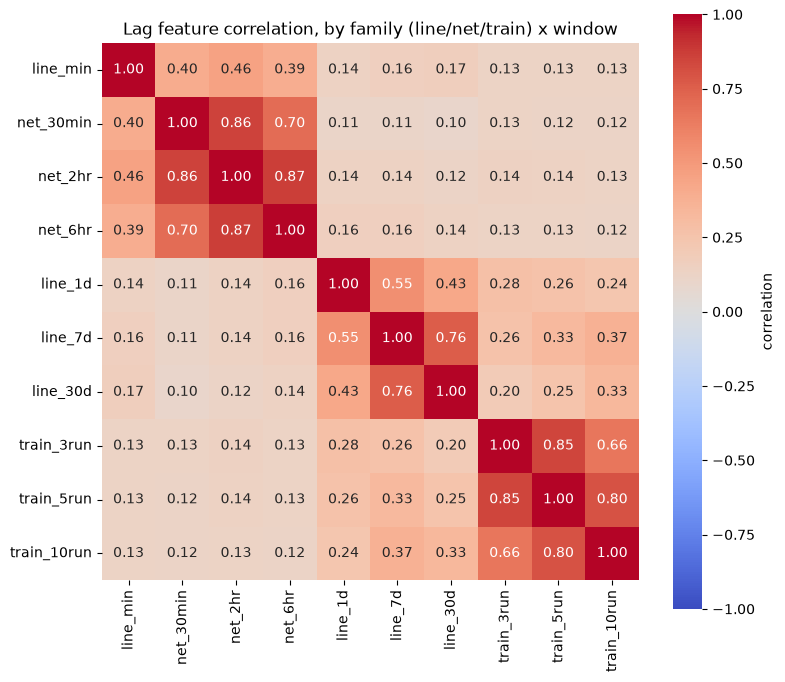

In [29]:
fig, ax = plt.subplots(figsize = (8, 7))
sns.heatmap(lag_corr, annot = True, fmt = ".2f", cmap = "coolwarm", vmin = -1, vmax = 1,
            square = True, cbar_kws = {"label": "correlation"}, ax = ax)
ax.set_title("Lag feature correlation, by family (line/net/train) x window")
plt.tight_layout()
plt.show()

Within each grouping, the different window sizes are very redundant with each other. 
The three network windows run 0.70-0.86 pairwise, the three train-run windows 0.66-0.85, and the three line-trend windows 0.43-0.76. 
Across groups, correlation drops by a lot, so the three groups (train/line/network) are capturing genuinely different signal. 

I'll keep all 3 groupings for modeling but pick one or two window sizes per.

## Misc outstanding

In [30]:
# lateness distribution / percentiles
print(df["lateness"].describe(percentiles = [0.5, 0.9, 0.95, 0.99, 0.999]))

count    1.551754e+06
mean     3.418282e+00
std      8.152469e+00
min      0.000000e+00
50%      1.000000e+00
90%      8.000000e+00
95%      1.300000e+01
99%      3.700000e+01
99.9%    9.700000e+01
max      1.430000e+03
Name: lateness, dtype: float64


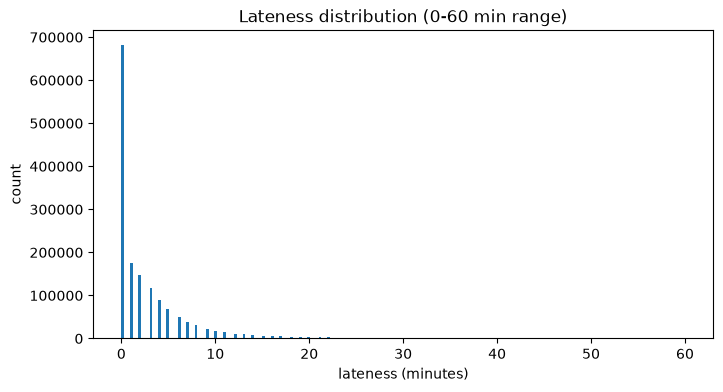

Runs with lateness > 60 min: 5,315 (0.3425%)
Runs with lateness > 120 min: 353 (0.0227%)


In [31]:
fig, ax = plt.subplots(figsize = (8, 4))
ax.hist(df["lateness"], bins = 200, range = (0, 60))
ax.set_xlabel("lateness (minutes)")
ax.set_ylabel("count")
ax.set_title("Lateness distribution (0-60 min range)")
plt.show()

print(f"Runs with lateness > 60 min: {(df['lateness'] > 60).sum():,} ({(df['lateness'] > 60).mean():.4%})")
print(f"Runs with lateness > 120 min: {(df['lateness'] > 120).sum():,} ({(df['lateness'] > 120).mean():.4%})")

Same long-tail shape from original EDA. 44% of runs are exactly 0 minutes late, which would break a log transform (undefined at 0) -- the binary `is_otp`/`on_time` target I'll use sidesteps this. Runs past 60 min late are rare (0.34%) and only a few hundred exceed 120 min (0.02%).

In [32]:
# line-year OTP trends
line_year_otp = df.groupby(["line", "year"], observed = True)["on_time"].mean().unstack()
line_year_otp.to_parquet(f"{BASEPATH}/8_line_year_otp.parquet")
line_year_otp

year,2017,2018,2019,2020,2021,2022,2023,2024,2025
line,,,,,,,,,
Airport,0.888808,0.880783,0.899034,0.941975,0.926465,0.920124,0.920362,0.838386,0.809289
Chestnut Hill East,0.807945,0.821965,0.881283,0.892898,0.883112,0.900341,0.872939,0.841100,0.786240
Chestnut Hill West,0.837660,0.815646,0.837633,0.905116,0.903077,0.900889,0.914874,0.877717,0.797521
Cynwyd,0.929183,0.943026,0.930108,0.949254,0.922046,0.953311,0.958276,0.905121,0.859673
Fox Chase,0.880367,0.895574,0.906933,0.924963,0.925720,0.900932,0.872855,0.796141,0.784533
Lansdale/Doylestown,0.755274,0.785388,0.817459,0.868661,0.814667,0.792970,0.798965,0.770969,0.679267
Manayunk/Norristown,0.856660,0.827266,0.870275,0.903102,0.872079,0.848810,0.874278,0.862306,0.791835
Media/Elwyn,0.867461,0.861532,0.897307,0.877421,0.862141,0.906598,0.852174,NaN,NaN
Media/Wawa,NaN,NaN,NaN,NaN,NaN,0.845357,0.908350,0.836694,0.722752


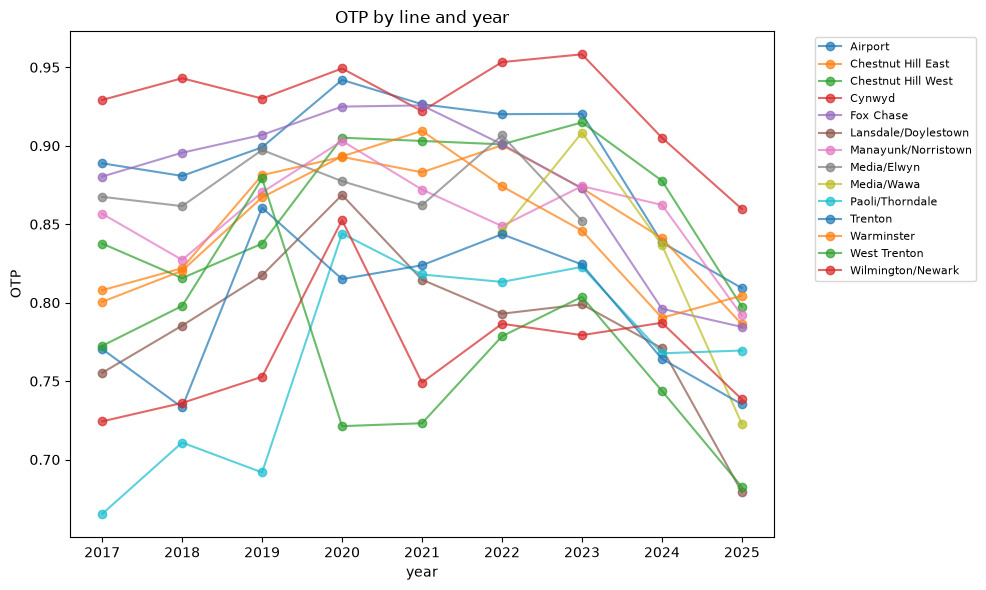

In [33]:
fig, ax = plt.subplots(figsize = (10, 6))
for line in line_year_otp.index:
    ax.plot(line_year_otp.columns, line_year_otp.loc[line], marker = "o", label = line, alpha = 0.7)
ax.set_xlabel("year")
ax.set_ylabel("OTP")
ax.set_title("OTP by line and year")
ax.legend(bbox_to_anchor = (1.05, 1), loc = "upper left", fontsize = 8)
plt.tight_layout()
plt.show()

### Report figure: compact by-line OTP trend

The report-ready version of this plot lives in `12_figures.ipynb`, which loads from
`8_line_year_otp.parquet` (cached above) instead of recomputing -- kept here only as the source of
that cache.

Most lines dip in 2024-2025. Media/Wawa only has data from 2022 onward (the Media/Elwyn extension opened Aug 2022; `line` deliberately keeps the two names separate bc they're distinct services rather than treating it as a pure rename).

In [34]:
# coverage flag (renamed from period_flag upstream)
print(df["coverage_flag"].value_counts())
df.groupby("coverage_flag", observed = True)["lateness"].agg(["mean", "median", "count"])

coverage_flag
normal    1522742
low         29012
Name: count, dtype: int64


,mean,median,count
coverage_flag,,,
low,3.474631,1.0,29012
normal,3.417208,1.0,1522742


`low`- and `normal`-coverage months show almost identical mean/median lateness. Reassuring that the low-coverage months aren't part of any larger systemwide issue.

In [35]:
# day of week
dow_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

dow_table = df.groupby("day_of_week", observed = True)["lateness"].agg(["mean", "median", "count"])
dow_table = dow_table.reindex(dow_order) if set(dow_order).issubset(dow_table.index) else dow_table
dow_table

,mean,median,count
day_of_week,,,
Monday,3.313349,1.0,247156
Tuesday,3.441675,1.0,253999
Wednesday,3.391203,1.0,254612
Thursday,3.485485,1.0,252564
Friday,3.228640,1.0,254304
Saturday,3.990924,2.0,148630
Sunday,3.226302,1.0,140489


Saturday is worst by a clear margin (3.99 mean, median jumps to 2)

In [36]:
# month
df.groupby("month", observed = True)["lateness"].agg(["mean", "median", "count"])

,mean,median,count
month,,,
1,3.502774,1.0,132650
2,3.287195,1.0,135180
3,3.112546,1.0,150498
4,2.965328,1.0,135468
5,2.826225,1.0,137776
6,3.555033,1.0,134918
7,3.452790,1.0,137682
8,3.453411,1.0,119353
9,3.370277,1.0,123232


October-December are worst, April-May best - might be weather-related?

In [37]:
# missingness
missing_summary = df.isna().sum()
missing_summary = missing_summary[missing_summary > 0].sort_values(ascending = False)
missing_pct = (missing_summary / len(df) * 100).round(2)

pd.DataFrame({"n_missing": missing_summary, "pct_missing": missing_pct})

,n_missing,pct_missing
wx_secondary,1529401,98.56
wx_primary_asof,1360353,87.67
daily_snow_24h_mm_asof,1351591,87.10
pressure_tendency_asof,1094201,70.51
pressure_3hr_change_hpa_asof,1094098,70.51
...,...,...
sched_terminus_sec,1481,0.10
terminus_stop_id,1481,0.10
origin_stop_id,1481,0.10
n_scheduled_stops,1481,0.10


The big missingness sources are expected ("NaN means no significant weather reported", per Charlotte's original R script): `wx_secondary` (98.6% missing here vs. 97.8% there) and `wx_primary_asof` (87.7% vs. 85.5%). `sched_headway_prior_min`/`_next_min` missing at 4.85% is the first/last-trip-of-the-day edge case.